<a href="https://colab.research.google.com/github/josephineabioye/msc-skincare-reaction-prediction/blob/main/notebooks/02_review_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
## Notebook Setup Cell

from google.colab import userdata, drive
import os

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USERNAME = 'josephineabioye'
REPO_NAME = 'msc-skincare-reaction-prediction'

if not os.path.exists(REPO_NAME):
    !git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git
    %cd {REPO_NAME}
else:
    %cd {REPO_NAME}
    !git pull

!git config user.email "josephineabioye@yahoo.com"
!git config user.name "Josephine Abioye"

drive.mount('/content/drive', force_remount=False)

DRIVE_PROJECT = '/content/drive/MyDrive/msc-skincare-project'
DATA_RAW = f'{DRIVE_PROJECT}/data/raw'
DATA_PROCESSED = f'{DRIVE_PROJECT}/data/processed'

print(f"Working in: {os.getcwd()}")

Cloning into 'msc-skincare-reaction-prediction'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 91 (delta 44), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 69.73 KiB | 11.62 MiB/s, done.
Resolving deltas: 100% (44/44), done.
/content/msc-skincare-reaction-prediction/msc-skincare-reaction-prediction
Mounted at /content/drive
Working in: /content/msc-skincare-reaction-prediction/msc-skincare-reaction-prediction


In [3]:
import pandas as pd

reviews = pd.read_csv(f"{DATA_RAW}/reviews_0-250.csv")

print("Shape (rows, columns):", reviews.shape)
print("\nColumn names:")
print(reviews.columns.tolist())

/tmp/ipykernel_518/624031004.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv(f"{DATA_RAW}/reviews_0-250.csv")


Shape (rows, columns): (602130, 19)

Column names:
['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd']


In [4]:
## sampling the data

reviews[['rating', 'is_recommended', 'product_name', 'review_text']].head(10)

,rating,is_recommended,product_name,review_text
0,5,1.0,Gentle Hydra-Gel Face Cleanser,I use this with the Nudestix “Citrus Clean Bal...
1,1,0.0,Lip Sleeping Mask Intense Hydration with Vitam...,I bought this lip mask after reading the revie...
2,5,1.0,Lip Sleeping Mask Intense Hydration with Vitam...,My review title says it all! I get so excited ...
3,5,1.0,Lip Sleeping Mask Intense Hydration with Vitam...,I’ve always loved this formula for a long time...
4,5,1.0,Lip Sleeping Mask Intense Hydration with Vitam...,"If you have dry cracked lips, this is a must h..."
5,4,1.0,Lip Sleeping Mask Intense Hydration with Vitam...,The scent isn’t my favourite but it works grea...
6,2,0.0,Lip Sleeping Mask Intense Hydration with Vitam...,I’ll give this 2 stars for nice packaging and ...
7,5,1.0,Lip Sleeping Mask Intense Hydration with Vitam...,I use this at night or while I’m putting makeu...
8,5,1.0,Lip Sleeping Mask Intense Hydration with Vitam...,I love this stuff. I first had the sample size...
9,5,1.0,Lip Sleeping Mask Intense Hydration with Vitam...,I purchased the Sweet Candy scent at my local ...


In [5]:
## view of the skin type distribution

print("SKIN TYPE:")
print(reviews['skin_type'].value_counts(dropna=False))
print("\nSKIN TONE:")
print(reviews['skin_tone'].value_counts(dropna=False))

SKIN TYPE:
skin_type
combination    292308
dry             99574
NaN             74683
normal          69435
oily            66130
Name: count, dtype: int64

SKIN TONE:
skin_tone
light          141402
fair           112076
lightMedium    106251
NaN            106056
medium          37221
mediumTan       34428
fairLight       30612
tan             17789
deep            10864
rich             2896
olive            1131
porcelain        1040
dark              322
notSureST          41
ebony               1
Name: count, dtype: int64


In [6]:
## Reload product data file with only skincare products

products = pd.read_csv(f"{DATA_RAW}/product_info.csv")
skincare = products[products['primary_category'] == 'Skincare'].copy()


## Set product_id of all skincare products as skincare_ids and confirm

skincare_ids = set(skincare['product_id'])

print("Skincare products:", len(skincare))
print("Unique skincare product_ids:", len(skincare_ids))


Skincare products: 2420
Unique skincare product_ids: 2420


In [7]:
## Filter all review files to skincare and consolidate

review_files = ["reviews_0-250.csv",
                "reviews_250-500.csv",
                "reviews_500-750.csv",
                "reviews_750-1250.csv",
                "reviews_1250-end.csv",]

filtered_pieces = []

for fname in review_files:
     df = pd.read_csv(f"{DATA_RAW}/{fname}", low_memory=False)
     skincare_slice = df[df['product_id'].isin(skincare_ids)]
     filtered_pieces.append(skincare_slice)
     print(f"{fname}: {len(df):>7} reviews loaded, {len(skincare_slice):>7} are skincare")
     del df

skincare_reviews = pd.concat(filtered_pieces, ignore_index=True)

print("\nConsolidated skincare reviews:", len(skincare_reviews))



reviews_0-250.csv:  602130 reviews loaded,  602130 are skincare
reviews_250-500.csv:  206725 reviews loaded,  206725 are skincare
reviews_500-750.csv:  116262 reviews loaded,  116262 are skincare
reviews_750-1250.csv:  119317 reviews loaded,  119317 are skincare
reviews_1250-end.csv:   49977 reviews loaded,   49977 are skincare

Consolidated skincare reviews: 1094411


In [8]:
## verify all reviews are skincare only even though the dataset says so

non_skincare = set(skincare_reviews['product_id']) - skincare_ids

print(f"Non-skincare product_ids found: {len(non_skincare)}")

Non-skincare product_ids found: 0


In [9]:
## dataset distribution

print("BY SKIN TYPE DISTRIBUTION:")
print(skincare_reviews['skin_type'].value_counts(dropna=False))

print("\nBY SKIN TONE DISTRIBUTION:")
print(skincare_reviews['skin_tone'].value_counts(dropna=False))

BY SKIN TYPE DISTRIBUTION:
skin_type
combination    544513
dry            185937
normal         131910
oily           120494
NaN            111557
Name: count, dtype: int64

BY SKIN TONE DISTRIBUTION:
skin_tone
light          266418
fair           208034
lightMedium    196541
NaN            170539
medium          70486
mediumTan       62456
fairLight       56228
tan             33678
deep            20601
rich             5493
olive            1730
porcelain        1612
dark              522
notSureST          70
ebony               3
Name: count, dtype: int64


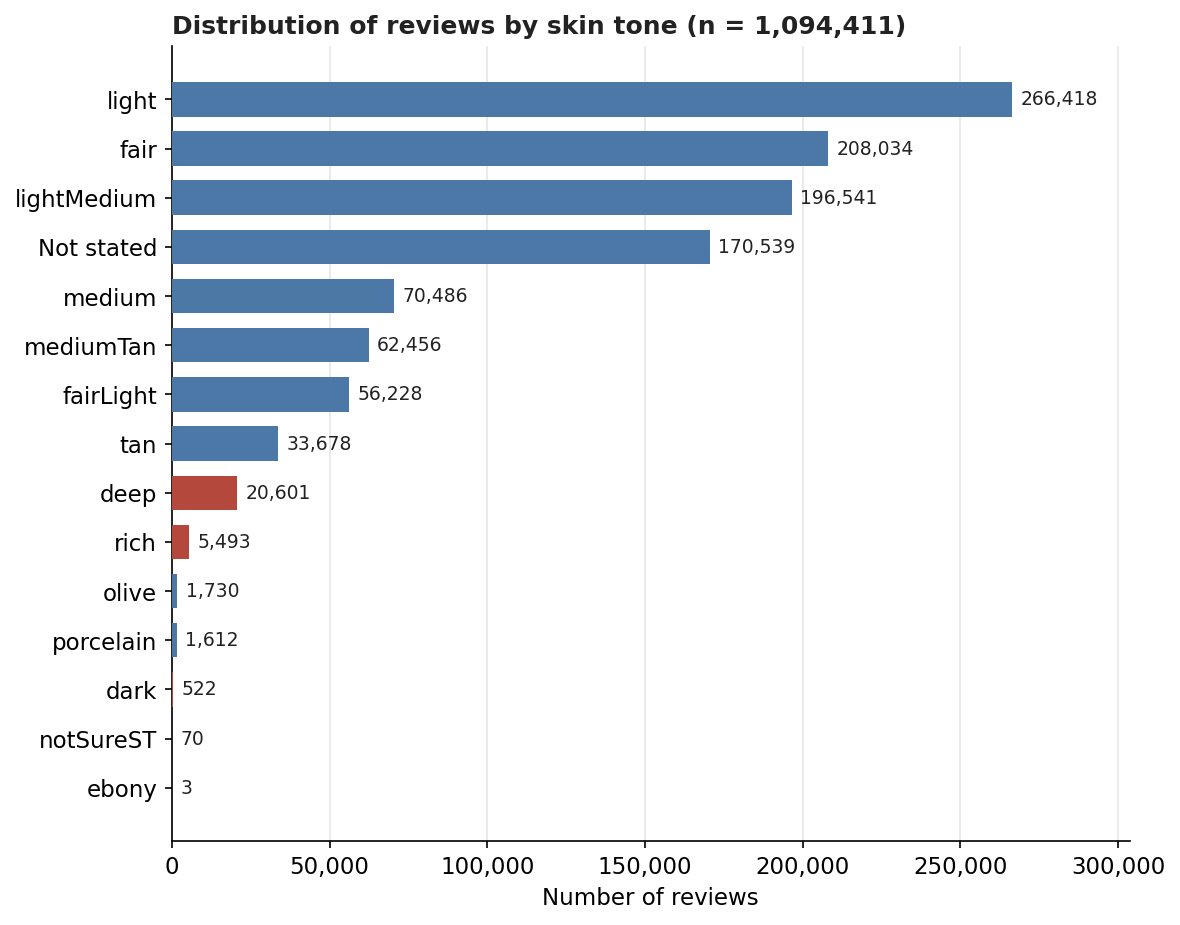

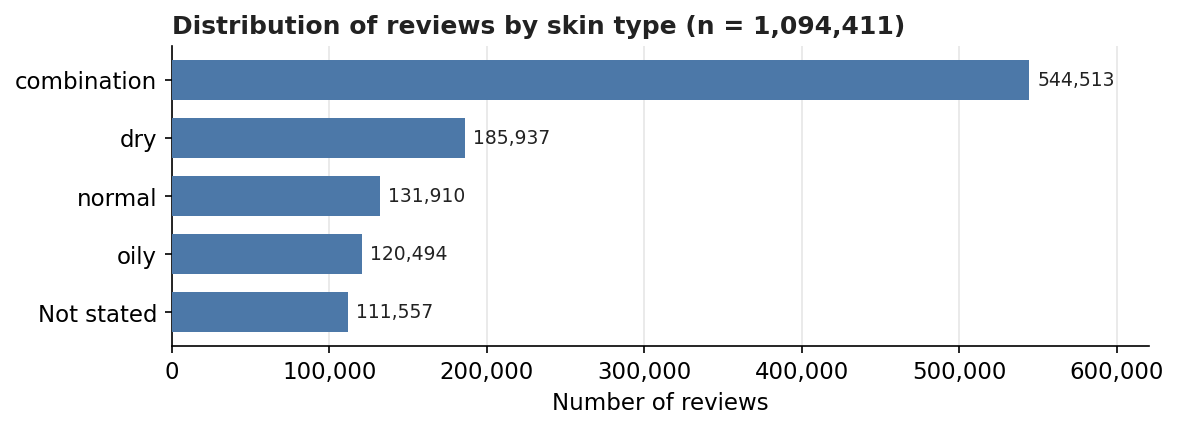

In [12]:
#Distribution Chart

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

reviews = pd.read_parquet(f"{DATA_PROCESSED}/skincare_reviews.parquet")

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 150, 'font.size': 11,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': '#E6E6E6', 'grid.linewidth': 0.8,
})
BAR, HL, INK = '#4C78A8', '#B4483C', '#222222'

def hbar(cats, vals, title, xlabel, fname, highlight=None):
    order = sorted(range(len(vals)),
                   key=lambda i:
                   vals[i],
                   reverse=True
                   )
    cats = [cats[i] for i in order];
    vals = [vals[i] for i in order]
    colors = [HL if (highlight and c in highlight)
                 else BAR for c in cats
              ]
    fig, ax = plt.subplots(
        figsize=(8, max(3, 0.42*len(cats)))
        )
    y = range(len(cats))
    ax.barh(y,
            vals,
            color=colors,
            height=0.7,
            zorder=3
            )
    ax.set_yticks(list(y));
    ax.set_yticklabels(cats);
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x,_: f'{int(x):,}'
            )
        )
    ax.set_xlabel(xlabel)
    ax.set_title(title,
                 loc='left',
                 fontsize=12,
                 fontweight='bold',
                 color=INK)
    ax.grid(axis='y', visible=False)
    xmax = max(vals)
    for yi, v in zip(y, vals):
        ax.text(v + xmax*0.01, yi, f'{v:,}', va='center', ha='left', fontsize=9, color=INK)
    ax.set_xlim(0, xmax*1.14); fig.tight_layout()
    fig.savefig(fname, bbox_inches='tight'); plt.show()

n = len(reviews)

tone = reviews['skin_tone'].fillna('Not stated').value_counts()
hbar(list(tone.index), list(tone.values),
     f'Distribution of reviews by skin tone (n = {n:,})',
     'Number of reviews', 'fig_skin_tone.png',
     highlight={'deep','rich','dark','ebony'})

stype = reviews['skin_type'].fillna('Not stated').value_counts()
hbar(list(stype.index), list(stype.values),
     f'Distribution of reviews by skin type (n = {n:,})',
     'Number of reviews', 'fig_skin_type.png')

In [13]:
import os
os.makedirs(DATA_PROCESSED, exist_ok=True)

skincare_reviews.to_parquet(f"{DATA_PROCESSED}/skincare_reviews.parquet")
print("Rows saved:", len(skincare_reviews))

Rows saved: 1094411


In [14]:
# A preliminary positive-rate estimate with some reaction related keywords.

reaction_terms = [
    "irritat", "breakout", "break out", "broke out", "burning", "burned", "sting",
    "rash", "itch", "redness", "red ", "inflam", "allergic", "allerg", "reaction",
    "purge", "purging", "clogged", "clog ", "acne", "pimple", "blackhead",
    "dry out", "dried out", "peeling", "flake", "swell", "bump", "blemish",
    "sensitiv", "hives", "blister", "rosacea", "eczema"
]

text = skincare_reviews["review_text"].fillna("").str.lower()
pattern = "|".join(reaction_terms)
contains_reaction = text.str.contains(pattern, regex=True)

n_pos = contains_reaction.sum()
n_total = len(skincare_reviews)
print(f"Reviews containing reaction-related language: {n_pos:,} of {n_total:,}")
print(f"Preliminary positive-rate estimate (upper bound): {100*n_pos/n_total:.2f}%")

Reviews containing reaction-related language: 413,993 of 1,094,411
Preliminary positive-rate estimate (upper bound): 37.83%


Review Data Exploration

This notebook loads the five review files, verifies they are all skincare reviews and consolidates them into a single dataset resulting to 1,094,411 total reviews. it also examines the fields; skin_type and skin_tone for the stratified analysis. Its obvious Skin_type has four well-populated categories while skin_tone is heavily skewed towards lighter tones.